In [161]:
import sys
import math
import matplotlib.pyplot as plt
import pandas as pd
import heapq


In [162]:
import matplotlib.pyplot as plt


def preparar_coords(coords):
    return {int(id_): (x, y) for id_, x, y in coords}


def configurar_plot(titulo):
    plt.figure(figsize=(18, 8))
    plt.title(titulo, fontsize=16)
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.grid(True, alpha=0.3)


def desenhar_vertices(coords_dict):
    for vertice, (x, y) in coords_dict.items():
        plt.scatter(x, y, s=90, zorder=3)
        plt.text(
            x,
            y,
            str(vertice),
            fontsize=12,
            verticalalignment="bottom",
            horizontalalignment="right",
            zorder=4
        )


def desenhar_aresta(coords_dict, u, v, peso=None, mostrar_peso=True, linewidth=2, alpha=1):
    x1, y1 = coords_dict[u]
    x2, y2 = coords_dict[v]

    plt.plot(
        [x1, x2],
        [y1, y2],
        linewidth=linewidth,
        alpha=alpha,
        zorder=1
    )

    if mostrar_peso and peso is not None:
        xm = (x1 + x2) / 2
        ym = (y1 + y2) / 2

        plt.text(
            xm,
            ym,
            str(peso),
            fontsize=9,
            zorder=2
        )


def plotar_agm(coords, agm, titulo, custo):
    coords_dict = preparar_coords(coords)

    configurar_plot(f"{titulo} - Custo: {custo:.2f}")

    for peso, vertice, pai in agm:
        desenhar_aresta(
            coords_dict,
            pai,
            vertice,
            peso=peso,
            mostrar_peso=True,
            linewidth=2,
            alpha=1
        )

    desenhar_vertices(coords_dict)
    plt.show()


def plotar_grafo(coords, matriz):
    coords_dict = preparar_coords(coords)
    n = len(coords)

    configurar_plot("Grafo Completo")

    for i in range(1, n + 1):
        for j in range(i + 1, n + 1):
            peso = matriz[i - 1][j - 1]

            if peso != 0:
                desenhar_aresta(
                    coords_dict,
                    i,
                    j,
                    peso=peso,
                    mostrar_peso=True,
                    linewidth=1,
                    alpha=0.25
                )

    desenhar_vertices(coords_dict)
    plt.show()


def plotar_ciclo(coords, ciclo, custo, matriz, titulo="Ciclo Hamiltoniano"):
    coords_dict = preparar_coords(coords)

    configurar_plot(f"{titulo} - Custo: {custo:.2f}")

    for i in range(len(ciclo) - 1):
        u = ciclo[i]
        v = ciclo[i + 1]

        peso = matriz[u - 1][v - 1]

        desenhar_aresta(
            coords_dict,
            u,
            v,
            peso=peso,
            mostrar_peso=True,
            linewidth=2,
            alpha=1
        )

    desenhar_vertices(coords_dict)
    plt.show()


def plotar_tour(coords, tour, titulo="Tour"):
    coords_dict = preparar_coords(coords)

    configurar_plot(titulo)

    for i in range(len(tour) - 1):
        u = tour[i]
        v = tour[i + 1]

        desenhar_aresta(
            coords_dict,
            u,
            v,
            peso=None,
            mostrar_peso=False,
            linewidth=2,
            alpha=1
        )

    desenhar_vertices(coords_dict)
    plt.show()

In [163]:
def ler_tsp_arquivo(caminho_arquivo):
    coords = []
    lendo = False

    with open(caminho_arquivo, 'r') as f:
        for linha in f:
            linha = linha.strip()

            if linha == "NODE_COORD_SECTION":
                lendo = True
                continue

            if linha == "EOF":
                break

            if lendo:
                partes = linha.split()
                id = int(partes[0])
                x = float(partes[1])
                y = float(partes[2])
                coords.append((id, x, y))

    return coords


def ler_tour(caminho_arquivo):
    tour = []
    peso_total = None
    lendo_tour = False

    with open(caminho_arquivo, "r", encoding="utf-8") as arquivo:
        for linha in arquivo:
            linha = linha.strip()

            if linha.startswith("TOTAL_WEIGHT"):
                peso_total = int(linha.split(":")[1].strip())

            elif linha == "TOUR_SECTION":
                lendo_tour = True

            elif linha == "EOF":
                break

            elif lendo_tour:
                tour.append(int(linha))

    # fecha o ciclo voltando ao primeiro vértice
    if tour[0] != tour[-1]:
        tour.append(tour[0])

    return tour, peso_total


def salvar_tour(
    caminho_saida,
    nome_instancia,
    nomes_alunos,
    metodo,
    tour,
    custo_total
):
    if tour[0] == tour[-1]:
        tour_sem_repetir = tour[:-1]
    else:
        tour_sem_repetir = tour

    with open(caminho_saida, "w", encoding="utf-8") as arquivo:
        arquivo.write(f"NAME: {nome_instancia}\n")
        arquivo.write(f"COMMENT: {nomes_alunos} - método utilizado: {metodo}\n")
        arquivo.write("TYPE: TOUR\n")
        arquivo.write(f"DIMENSION: {len(tour_sem_repetir)}\n")
        arquivo.write(f"TOTAL_WEIGHT: {custo_total}\n")
        arquivo.write("TOUR_SECTION\n")

        for cidade in tour_sem_repetir:
            arquivo.write(f"{cidade}\n")

        arquivo.write("EOF\n")

In [164]:
def calcular_distancia(cidade1, cidade2):
    _, xi, yi = cidade1
    _, xj, yj = cidade2

    dist = math.sqrt((xi - xj)**2 + (yi - yj)**2)
    return math.floor(0.5 + dist)

In [165]:
def criar_matriz_distancias(coords):
    n = len(coords)

    matriz = [[0 for _ in range(n)] for _ in range(n)]

    for i in range(n):
        for j in range(n):
            if i != j:
                matriz[i][j] = calcular_distancia(coords[i], coords[j])

    return matriz

def imprimir_matriz_com_ids(coords, matriz):
    ids = [cidade[0] for cidade in coords]

    print("     ", end="")
    for id_cidade in ids:
        print(f"{id_cidade:6}", end="")
    print()

    for i, linha in enumerate(matriz):
        print(f"{ids[i]:5}", end="")
        for valor in linha:
            print(f"{valor:6}", end="")
        print()

In [166]:

# Prim_matriz Adaptado de: https://www.programiz.com/dsa/prim-algorithm
def prim_matriz(grafo, inicio=0):
    n = len(grafo)

    selecionado = [False] * n
    selecionado[inicio] = True

    agm = []
    custo_total = 0

    while len(agm) < n - 1:
        menor_peso = float("inf")
        origem = -1
        destino = -1

        # Percorre todos os vértices já selecionados
        for i in range(n):
            if selecionado[i]:
                # Procura a menor aresta para um vértice ainda não selecionado
                for j in range(n):
                    if not selecionado[j] and grafo[i][j] != 0:
                        if grafo[i][j] < menor_peso:
                            menor_peso = grafo[i][j]
                            origem = i
                            destino = j

        if destino == -1:
            raise ValueError("O grafo é desconexo. Não é possível gerar uma AGM.")

        selecionado[destino] = True
        agm.append(( menor_peso, destino + 1, origem + 1))
        custo_total += menor_peso

    return agm, custo_total

In [167]:
#Emparelhamento Perfeito

def encontrar_vertices_impares(agm, n):
    grau = [0] * n

    for peso, vertice, pai in agm:
        grau[vertice - 1] += 1
        grau[pai - 1] += 1

    impares = []

    for i in range(n):
        if grau[i] % 2 != 0:
            impares.append(i + 1)

    return impares


def emparelhamento_guloso(impares, matriz):
    impares = impares.copy()
    pares = []
    custo_total = 0

    while impares:
        v = impares.pop(0)

        melhor_u = None
        melhor_peso = float("inf")
        melhor_indice = -1

        for i, u in enumerate(impares):
            peso = matriz[v - 1][u - 1]

            if peso < melhor_peso:
                melhor_peso = peso
                melhor_u = u
                melhor_indice = i

        impares.pop(melhor_indice)

        pares.append((melhor_peso, v, melhor_u))
        custo_total += melhor_peso

    return pares, custo_total

In [168]:
def construir_multigrafo(arestas, n):

    grafo = {i: [] for i in range(1, n + 1)}

    for peso, u, v in arestas:

        grafo[u].append(v)
        grafo[v].append(u)

    return grafo


def ciclo_euleriano(grafo):
    g = {v: sorted(vizinhos, reverse=True) for v, vizinhos in grafo.items()}
    
    pilha = [1]
    ciclo = []

    while pilha:
        topo = pilha[-1]
        
        if g[topo]:
            vizinho = g[topo].pop()
            g[vizinho].remove(topo)
            pilha.append(vizinho)
        else:
            ciclo.append(pilha.pop())
    
    ciclo.reverse()
    
    return ciclo

def ciclo_hamiltoniano(ciclo_euleriano):

    visitados = set()

    hamiltoniano = []

    for v in ciclo_euleriano:

        if v not in visitados:

            hamiltoniano.append(v)

            visitados.add(v)

    hamiltoniano.append(hamiltoniano[0])

    return hamiltoniano

def calcular_custo(ciclo, matriz):

    custo = 0

    for i in range(len(ciclo) - 1):

        u = ciclo[i]
        v = ciclo[i + 1]

        custo += matriz[u - 1][v - 1]

    return custo


In [169]:

#Referencia utilizada: https://slowandsteadybrain.medium.com/traveling-salesman-problem-ce78187cf1f3

def dois_opt(ciclo, matriz): 


    melhor = ciclo[:]
    melhor_custo = calcular_custo(melhor, matriz)

    melhorou = True

    while melhorou:
        melhorou = False

        for i in range(1, len(melhor) - 2):
            for j in range(i + 1, len(melhor) - 1):

                novo = melhor[:i] + melhor[i:j + 1][::-1] + melhor[j + 1:]
                novo_custo = calcular_custo(novo, matriz)

                if novo_custo < melhor_custo:
                    melhor = novo
                    melhor_custo = novo_custo
                    melhorou = True

    return melhor, melhor_custo

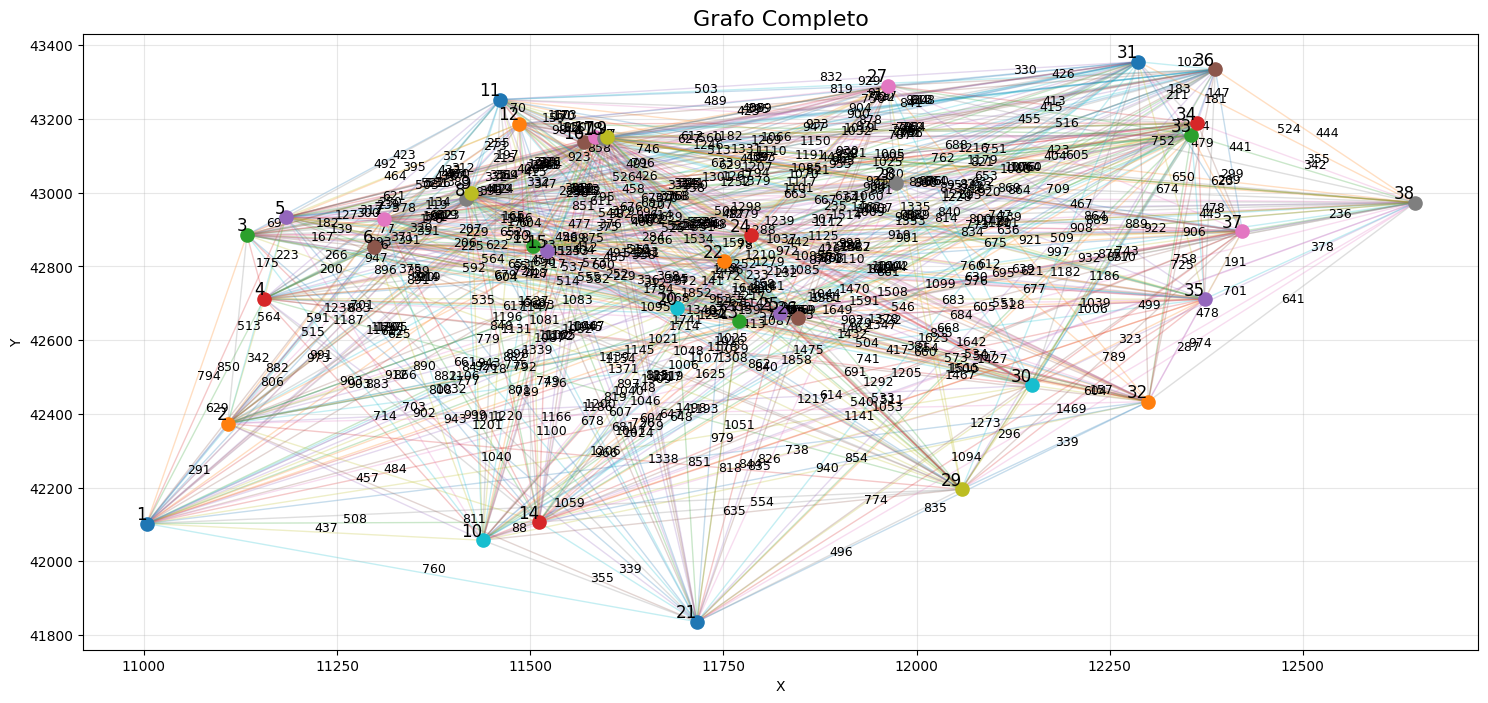

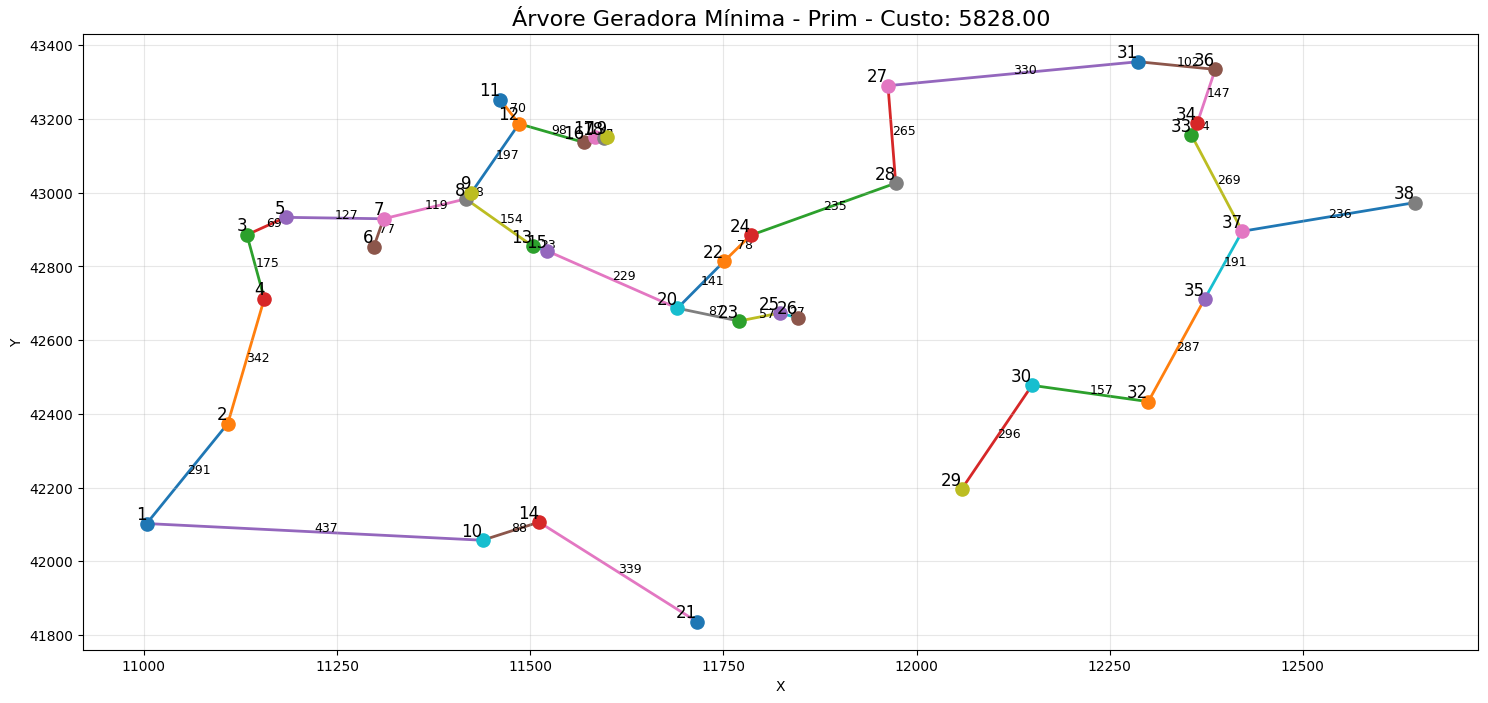

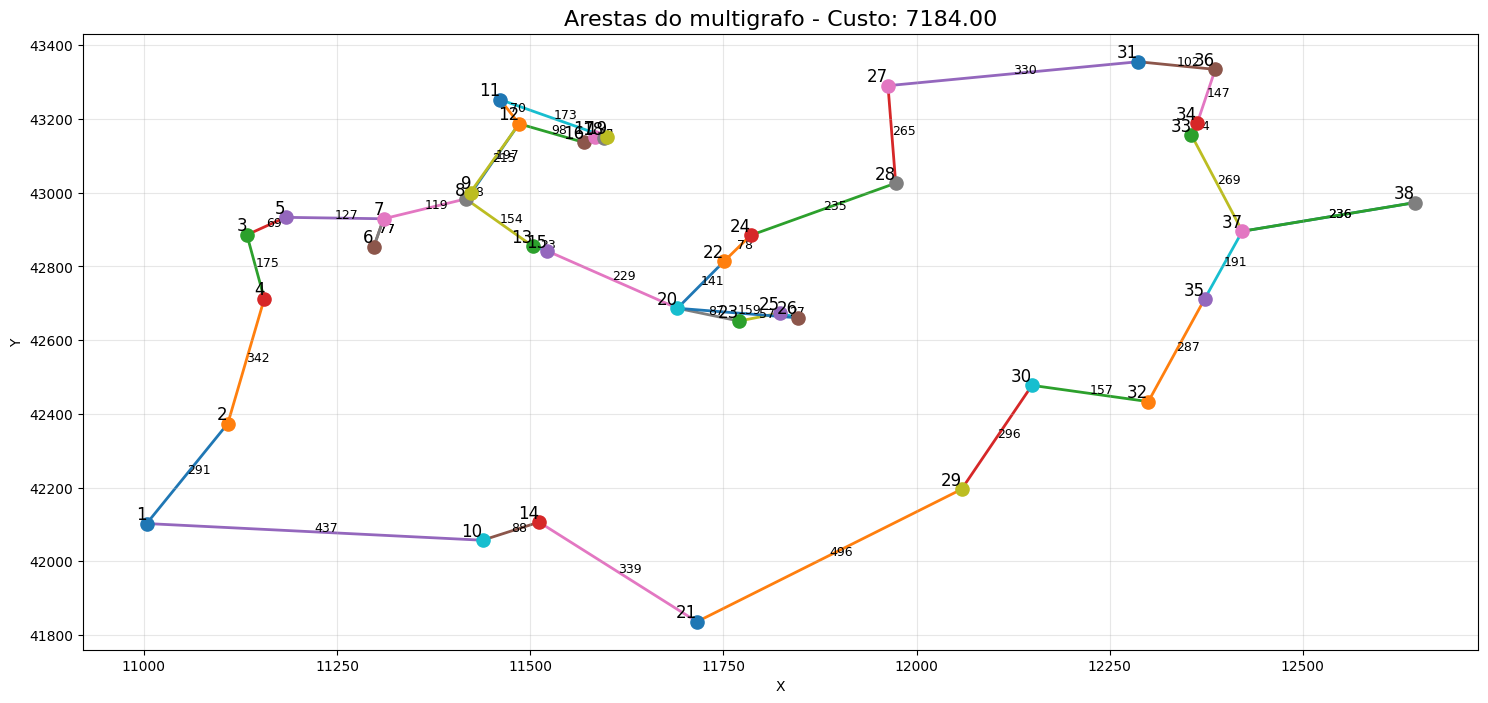

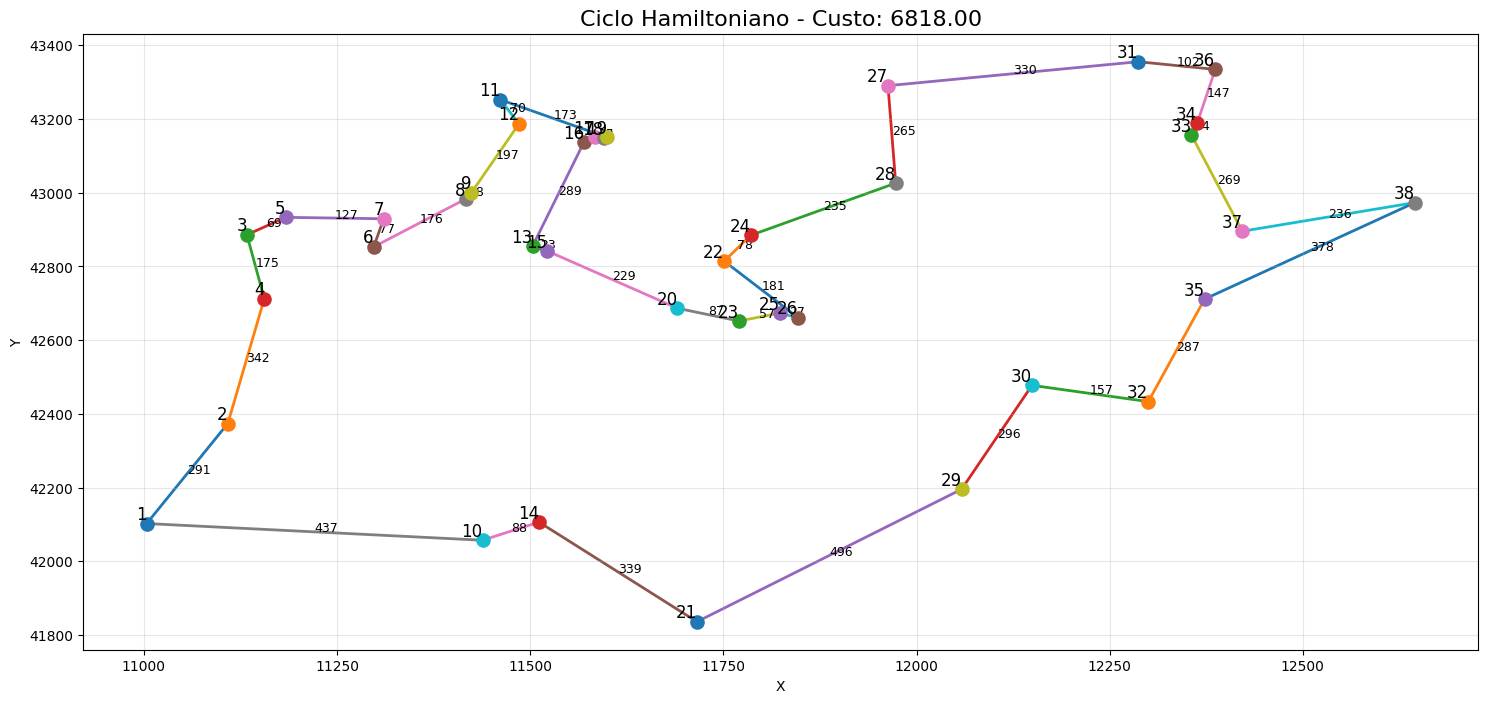

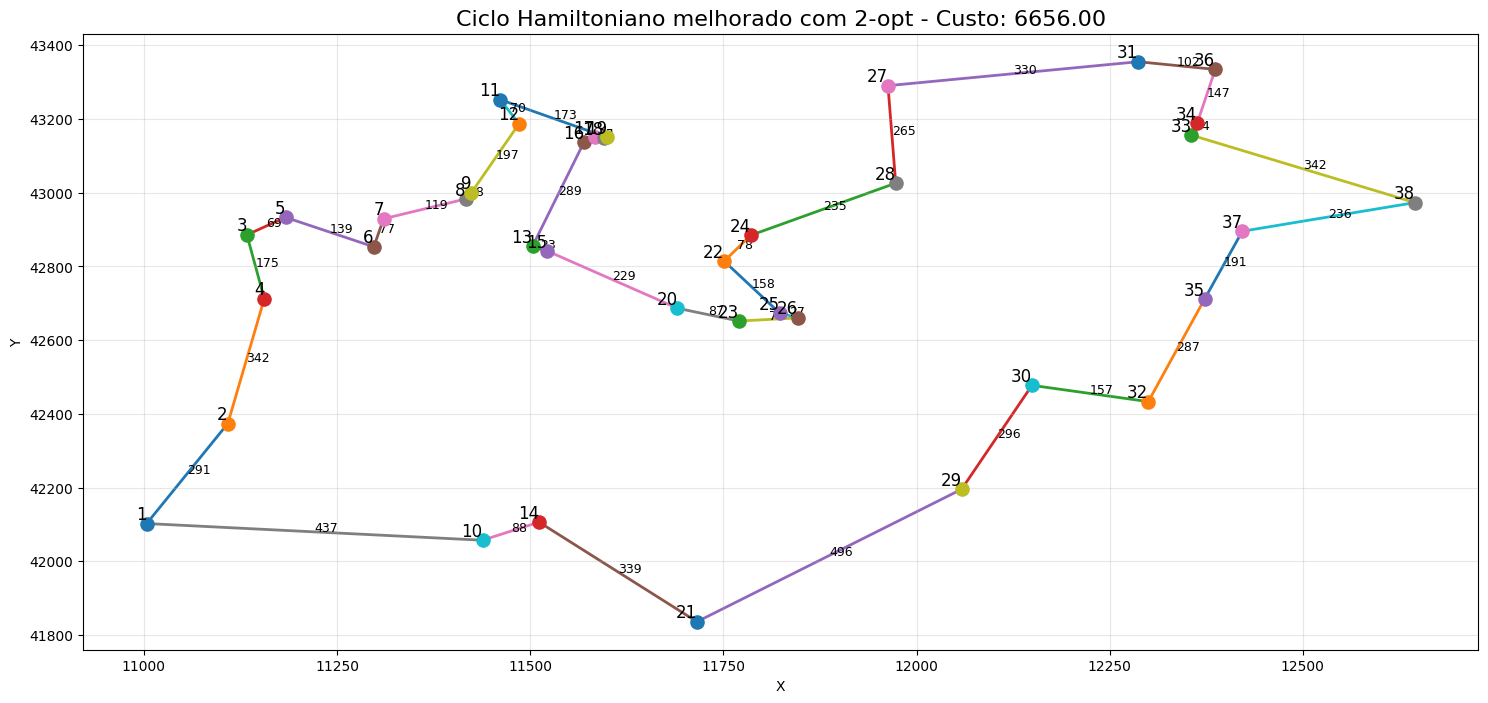

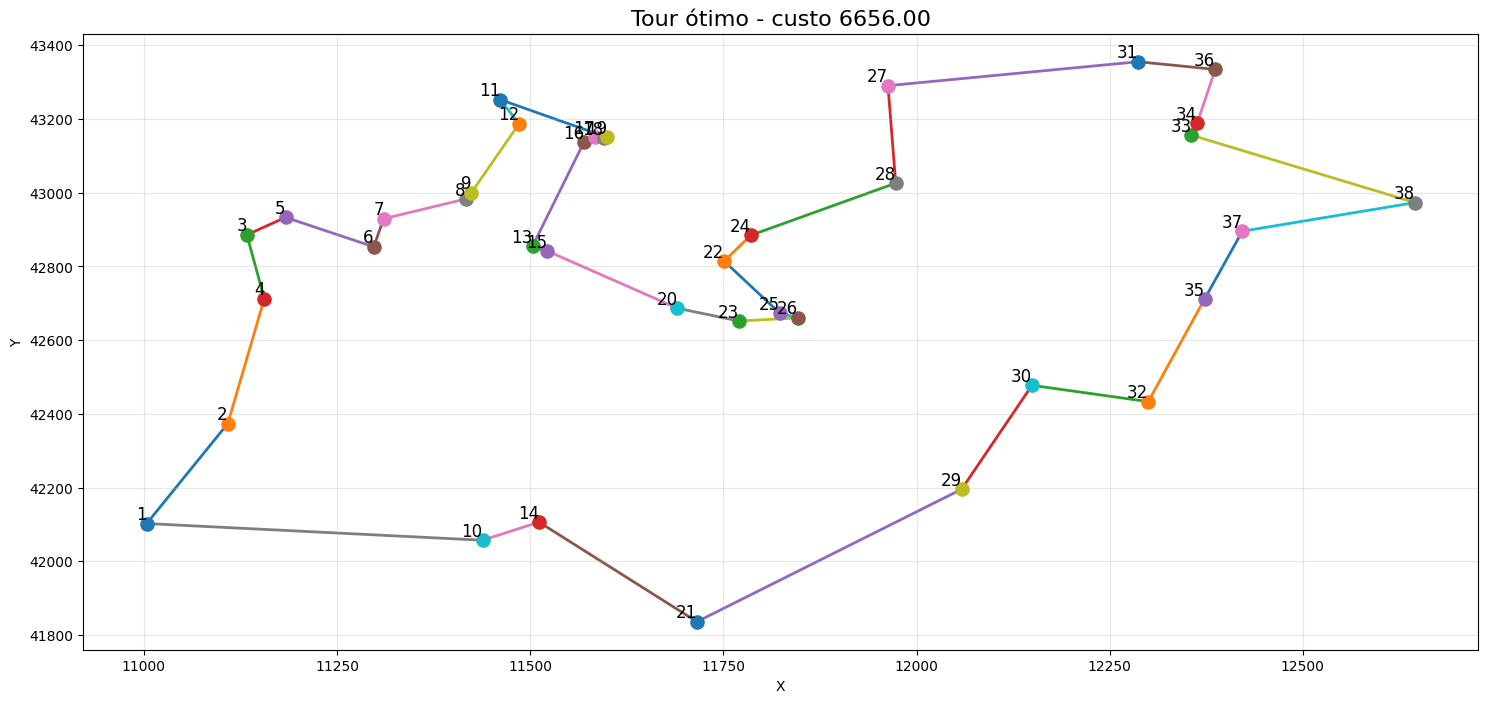

Custo ótimo: 6656
Custo AGM: 5828
Custo emparelhamento: 1356
Custo Christofides: 6656
Razão: 1.0


In [ ]:

instancia = 'tsp51.tsp'
coords = ler_tsp_arquivo(instancia)
matriz = criar_matriz_distancias(coords)

plotar_grafo(coords, matriz)

agm_matriz, custo_agm = prim_matriz(matriz)

plotar_agm(coords, agm_matriz, "Árvore Geradora Mínima - Prim", custo_agm)

impares = encontrar_vertices_impares(agm_matriz, len(matriz))

emparelhamento, custo_emp = emparelhamento_guloso(impares, matriz)

arestas_multigrafo = agm_matriz + emparelhamento

plotar_agm(coords, arestas_multigrafo, "Arestas do multigrafo", custo_agm + custo_emp)

grafo = construir_multigrafo(arestas_multigrafo, len(matriz))

ciclo_euler = ciclo_euleriano(grafo)

hamiltoniano = ciclo_hamiltoniano(ciclo_euler)

custo_hamiltoneano = calcular_custo(hamiltoniano, matriz)

plotar_ciclo(coords, hamiltoniano, custo_hamiltoneano, matriz)

hamiltoniano_melhorado, custo_final = dois_opt(hamiltoniano, matriz)

plotar_ciclo( coords, hamiltoniano_melhorado, custo_final, matriz, titulo="Ciclo Hamiltoniano melhorado com 2-opt")

tour_otimo, peso_otimo = ler_tour(instancia+".tour")

plotar_tour(coords, tour_otimo, f"Tour ótimo - custo {peso_otimo:.2f}")




salvar_tour(
    caminho_saida="Agm_final.tour",
    nome_instancia= instancia,
    nomes_alunos="Eric Albuquerque e Álvaro Freire",
    metodo="Christofides",
    tour=hamiltoniano,
    custo_total=custo_final
)


print("Custo ótimo:", peso_otimo)
print("Custo AGM:", custo_agm)
print("Custo emparelhamento:", custo_emp)
print("Custo Christofides:", custo_final)

if peso_otimo is not None and peso_otimo > 0:
    print("Razão:", custo_final / peso_otimo)
else:
    print("não foi possível calcular")